In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import random

# setup paths
DATA_DIR = "../data/raw/"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train_images")

C:\Users\azama\AppData\Local\Temp\ipykernel_27040\1207713270.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette='viridis')


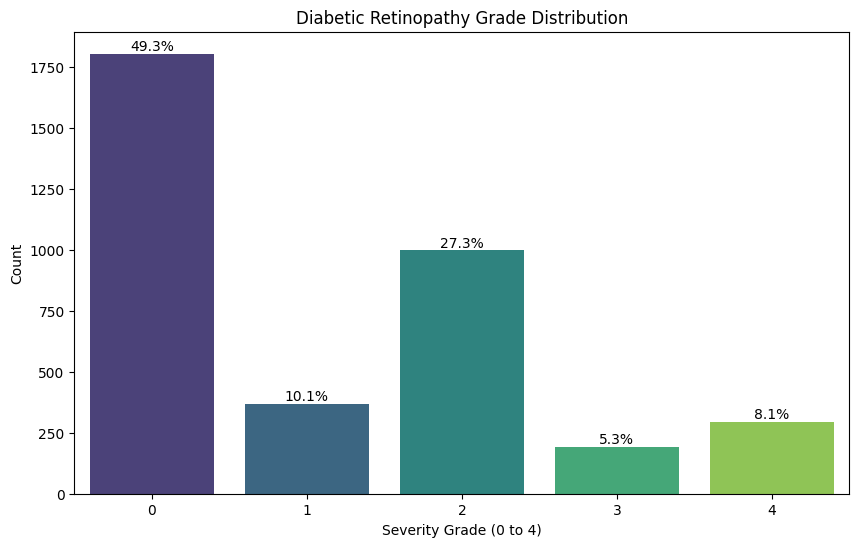

In [2]:
# load labels
df = pd.read_csv(TRAIN_CSV)

# plot distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='diagnosis', palette='viridis')
plt.title('Diabetic Retinopathy Grade Distribution')
plt.xlabel('Severity Grade (0 to 4)')
plt.ylabel('Count')

# show percentages
total = len(df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

C:\Users\azama\AppData\Local\Temp\ipykernel_27040\1634165316.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_imgs = df.groupby('diagnosis').apply(lambda x: x.sample(1)).reset_index(drop=True)


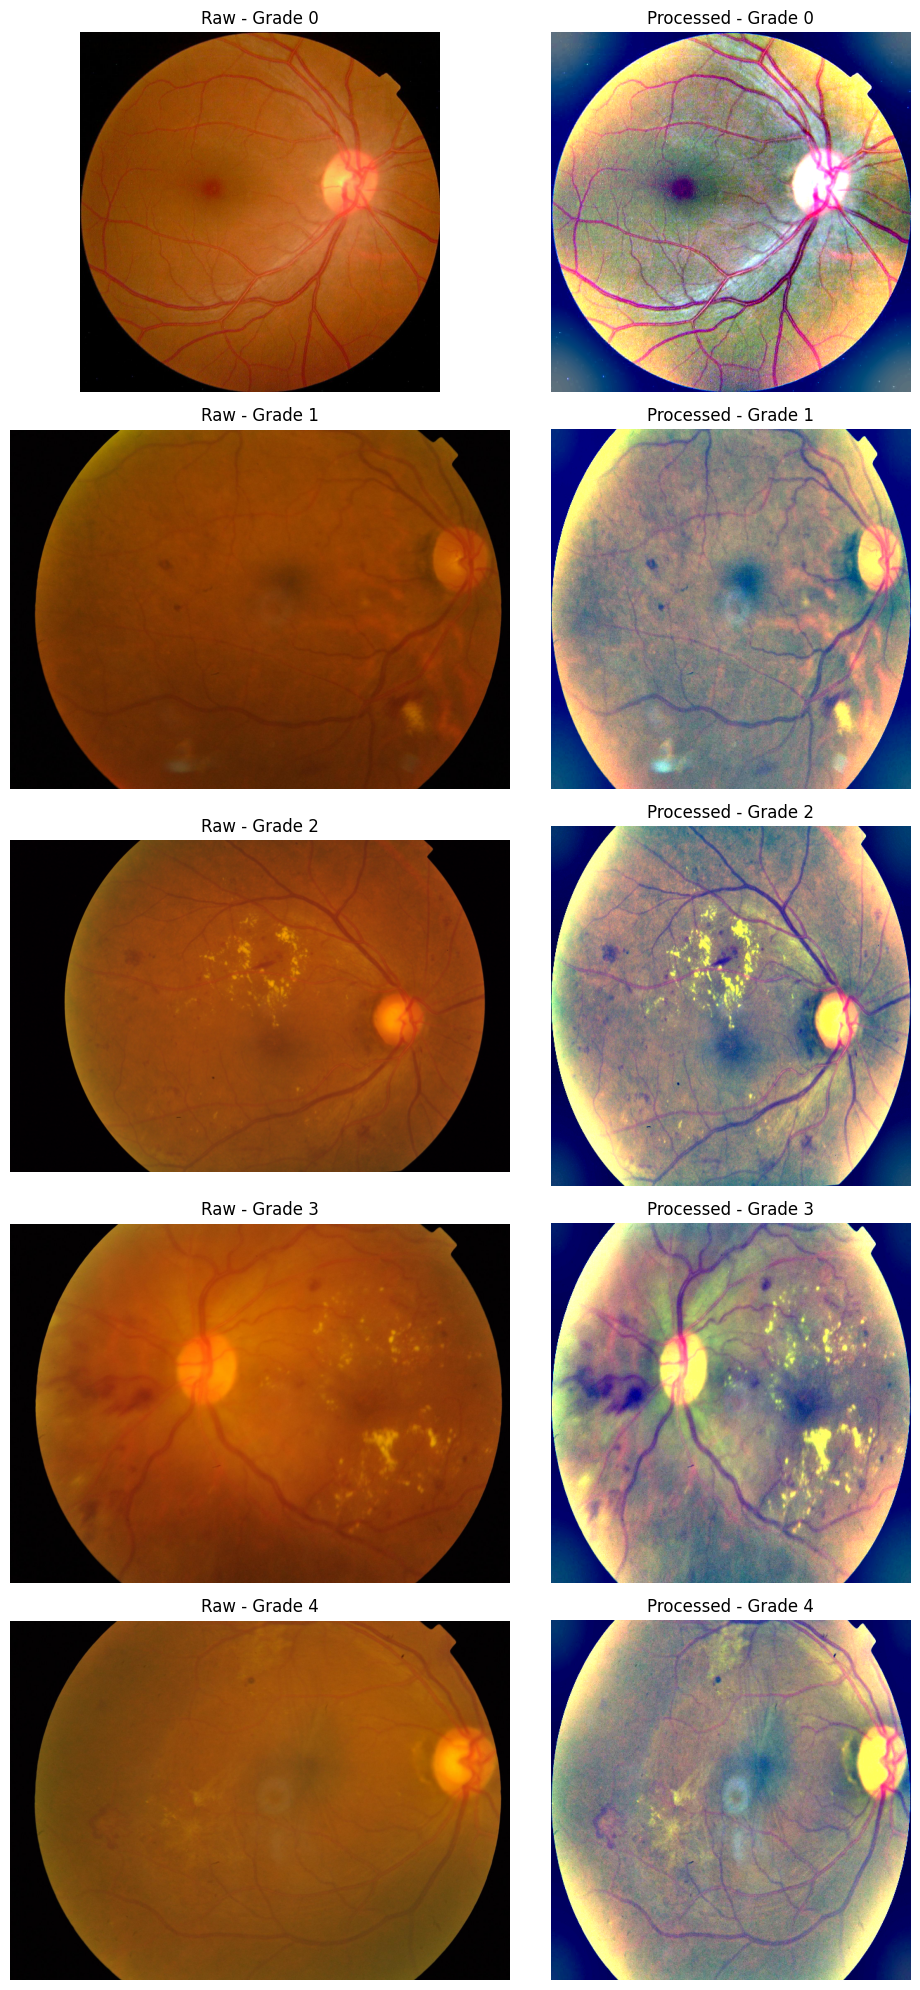

In [3]:
# import preprocessing func
import sys
sys.path.append('../')
from data.preprocess import ben_graham_preprocessing

# get random sample
sample_imgs = df.groupby('diagnosis').apply(lambda x: x.sample(1)).reset_index(drop=True)

fig, axes = plt.subplots(5, 2, figsize=(10, 20))

for idx, row in sample_imgs.iterrows():
    img_path = os.path.join(TRAIN_IMG_DIR, f"{row['id_code']}.png")
    
    # read raw
    raw_img = cv2.imread(img_path)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    
    # get processed
    processed_img = ben_graham_preprocessing(img_path)
    
    # plot raw
    axes[idx, 0].imshow(raw_img)
    axes[idx, 0].set_title(f"Raw - Grade {row['diagnosis']}")
    axes[idx, 0].axis('off')
    
    # plot processed
    axes[idx, 1].imshow(processed_img)
    axes[idx, 1].set_title(f"Processed - Grade {row['diagnosis']}")
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()